Saving global_air_quality_dataset.csv to global_air_quality_dataset.csv
First 5 rows:


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3



Shape of dataset: (3660, 13)

Columns: Index(['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)',
       'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)',
       'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              3660 non-null   object 
 1   City              3660 non-null   object 
 2   Country           3660 non-null   object 
 3   AQI               3660 non-null   int64  
 4   PM2.5 (µg/m³)     3660 non-null   float64
 5   PM10 (µg/m³)      3660 non-null   float64
 6   NO2 (ppb)         3660 non-null   float64
 7   SO2 (ppb)         3660 non-null   float64
 8   CO (ppm)          3660 non-null   float64
 9   O3 (ppb)          3660 non-null   float64
 10  Temperature (°C)  3660 non-null   float64
 11  Humidity

,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000
mean,164.642077,126.380574,154.785956,52.960710,25.940328,5.023842,105.325929,15.061913,50.657104,7.788907
std,78.571659,71.016089,84.045548,27.361413,14.001531,2.851573,55.032175,14.590761,23.195880,4.223788
min,30.000000,5.100000,10.000000,5.100000,2.000000,0.100000,10.100000,-10.000000,10.000000,0.500000
25%,96.000000,63.700000,82.200000,29.175000,13.700000,2.590000,57.900000,2.175000,31.000000,4.100000
50%,165.000000,125.850000,152.550000,52.800000,26.200000,4.910000,105.750000,15.000000,51.000000,7.800000
75%,233.000000,187.000000,227.600000,76.700000,38.200000,7.560000,152.925000,27.525000,71.000000,11.500000
max,300.000000,250.000000,300.000000,100.000000,50.000000,9.990000,200.000000,40.000000,90.000000,15.000000



Missing Values:
Date                0
City                0
Country             0
AQI                 0
PM2.5 (µg/m³)       0
PM10 (µg/m³)        0
NO2 (ppb)           0
SO2 (ppb)           0
CO (ppm)            0
O3 (ppb)            0
Temperature (°C)    0
Humidity (%)        0
Wind Speed (m/s)    0
dtype: int64

Duplicate Rows: 0

Numerical Columns: Index(['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)',
       'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)'],
      dtype='object')
Categorical Columns: Index(['Date', 'City', 'Country'], dtype='object')

Train size: (2562, 12)
Validation size: (549, 12)
Test size: (549, 12)

Validation Results:
MAE: 72.85460941115333
MSE: 7417.667099938059
RMSE: 86.12587938557179
R2 Score: -0.16258141689378403

Intercept: 165.62136221506196
Coefficients: [ -0.66149702   2.1888186    1.37063728  -0.38446949   0.21197076
   0.73989267  -0.46237798   2.04090238  -0.83499193  19.62080231
  -4.41924128  12.14374936

,Actual,Predicted
1242,103,148.148375
869,272,181.682700
450,44,130.496011
2132,67,160.166910
547,240,189.298488


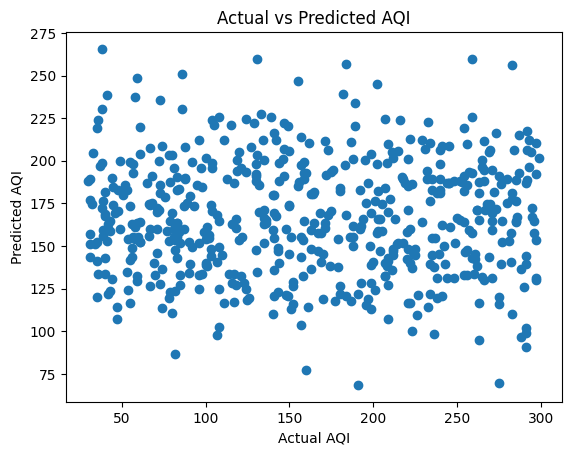

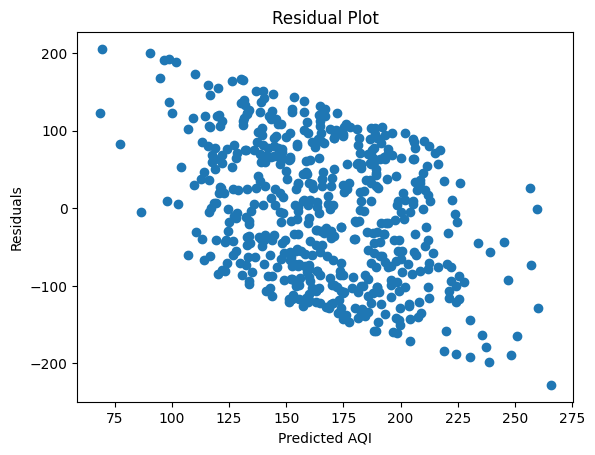


Model saved as aqi_model.pkl

Sample Prediction: [172.51715382]


In [3]:
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# STEP 2: UPLOAD DATASET MANUALLY

uploaded = files.upload()   # Upload your CSV file here

# Replace with your actual file name after upload
df = pd.read_csv(list(uploaded.keys())[0])

# Display first rows
print("First 5 rows:")
display(df.head())

# STEP 3: INITIAL EXPLORATION

print("\nShape of dataset:", df.shape)
print("\nColumns:", df.columns)

print("\nData Info:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

# STEP 4: DATA CLEANING

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing numeric values with mean
df = df.fillna(df.mean(numeric_only=True))

# Remove duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Clean categorical columns (if exist)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# STEP 5: FEATURE SELECTION

# Target variable
y = df['AQI']

# Feature variables
X = df.drop('AQI', axis=1)

#STEP 6: IDENTIFY NUMERIC & CATEGORICAL COLUMNS

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("\nNumerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# STEP 7: PREPROCESSING PIPELINE

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# STEP 8: TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)
print("\nTrain size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

# STEP 9: MODEL TRAINING

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
model.fit(X_train, y_train)

# STEP 10: VALIDATION EVALUATION

y_val_pred = model.predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)
print("\nValidation Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# STEP 11: MODEL INTERPRETATION

reg = model.named_steps['regressor']
print("\nIntercept:", reg.intercept_)
print("Coefficients:", reg.coef_)

# STEP 12: FINAL TEST EVALUATION

y_test_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("\nTest Results:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# STEP 13: ACTUAL VS PREDICTED TABLE

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})
print("\nSample Predictions:")
display(results.head())

# STEP 14: VISUALIZATION

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

# Residual Plot
residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals)
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# STEP 15: SAVE MODEL

joblib.dump(model, 'aqi_model.pkl')
print("\nModel saved as aqi_model.pkl")

# STEP 16: LOAD MODEL & TEST

loaded_model = joblib.load('aqi_model.pkl')

sample = X.iloc[0:1]
prediction = loaded_model.predict(sample)

print("\nSample Prediction:", prediction)



